# Reproducibility Study — Score Embedding Fast Diffusion
**Paper:** arXiv:2511.17634 — *Efficient Score Pre-computation for Diffusion Models via Cross-Matrix Krylov Projection*

Run cells top-to-bottom. Each section is independent — skip to any section if experiments are already complete.

| Section | What it does |
|---|---|
| 1. Setup | Imports, paths, helpers |
| 2. Cleanup | Remove stale artifacts, organise outputs |
| 3. KDE Scaling Benchmark | Time scipy vs histogram KDE across image resolutions |
| 4. Run Experiments | Main + ablation + comparison runs (can skip if saves/ already populated) |
| 5. Aggregate Results | Load timing/convergence CSVs, compute SSIM/FID summary tables |
| 6. Visualise | Convergence curves, runtime breakdowns, ablation sweeps, FID bar charts, sample grids |
| 7. Export | Save all figures to `figures/` and print LaTeX tables |

## 1. Setup & Imports

In [78]:
import os, sys, csv, re, time, glob
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("inline")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display, Image, Markdown

import torch
import torchvision.utils as vutils

# ── Project root ─────────────────────────────────────────────────────────────
ROOT = Path(os.path.abspath(""))
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "fast_diffusion"))
sys.path.insert(0, str(ROOT / "data"))

SAVES_DIR   = ROOT / "fast_diffusion" / "saves"
FIGURES_DIR = ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

print(f"Root:    {ROOT}")
print(f"Saves:   {SAVES_DIR}")
print(f"Figures: {FIGURES_DIR}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Root:    c:\Users\ana\Documents\GitHub\Score-Embedding-Fast-Diffusion
Saves:   c:\Users\ana\Documents\GitHub\Score-Embedding-Fast-Diffusion\fast_diffusion\saves
Figures: c:\Users\ana\Documents\GitHub\Score-Embedding-Fast-Diffusion\figures
CUDA available: True
GPU: NVIDIA RTX 2000 Ada Generation Laptop GPU


## 2. KDE Scaling Benchmark

Measures scipy `gaussian_kde` (O(N²)) vs histogram FFT (O(N log N)) KDE as a function of image resolution. Generates the scaling plot for the paper.

In [79]:
import scipy.stats
from scipy.ndimage import map_coordinates

def kde_scipy(xy_train):
    """Original O(N^2) scipy KDE."""
    kde = scipy.stats.gaussian_kde(xy_train)
    return np.log(kde(xy_train))

def kde_histogram(xy_train, n_bins=None):
    """Histogram FFT KDE -- O(N log N).

    Bins N points into a grid (O(N)), convolves with a Gaussian kernel
    via FFT (O(n_bins^2 log n_bins)), then interpolates back to data
    points (O(N)).  With n_bins ~ sqrt(N) the total cost is O(N log N).
    """
    x, y = xy_train[0], xy_train[1]
    n = xy_train.shape[1]
    if n_bins is None:
        # Scale n_bins ~ sqrt(N) so O(n_bins^2 log n_bins) = O(N log N)
        n_bins = max(64, int(np.sqrt(n) * 4))
    # Step 1: bin data -- O(N)
    hist, xe, ye = np.histogram2d(x, y, bins=n_bins, range=[[0,1],[0,1]], density=True)
    # Step 2: Gaussian smoothing via FFT -- O(n_bins^2 log n_bins)
    bw = n ** (-1.0 / 6.0)          # Scott's rule bandwidth in [0,1] units
    sigma_bins = bw * n_bins         # bandwidth in bin units
    freq_x = np.fft.rfftfreq(n_bins)
    freq_y = np.fft.fftfreq(n_bins)
    FX, FY = np.meshgrid(freq_x, freq_y)
    gauss_kernel = np.exp(-2 * np.pi**2 * sigma_bins**2 * (FX**2 + FY**2))
    smoothed = np.fft.irfft2(np.fft.rfft2(hist) * gauss_kernel, s=(n_bins, n_bins))
    smoothed = np.clip(smoothed, 1e-300, None)
    # Step 3: interpolate at data points -- O(N)
    xi = np.clip((x - xe[0]) / (xe[-1] - xe[0]) * n_bins, 0, n_bins - 1)
    yi = np.clip((y - ye[0]) / (ye[-1] - ye[0]) * n_bins, 0, n_bins - 1)
    return np.log(map_coordinates(smoothed, [xi, yi], order=1, mode='nearest'))

# Benchmark across resolutions: N_pixels = res * res
resolutions = [8, 16, 32, 64, 128, 192, 256]
n_repeats = 3

timing_rows = []
for res in resolutions:
    n_pixels = res * res
    rng = np.random.default_rng(42)
    xy = rng.random((2, n_pixels))

    # Scipy KDE (skip for large N -- too slow)
    t_scipy = None
    if n_pixels <= 32 * 32:
        times = []
        for _ in range(n_repeats):
            t0 = time.perf_counter()
            kde_scipy(xy)
            times.append(time.perf_counter() - t0)
        t_scipy = np.mean(times)
        print(f"  res={res:3d}x{res}  N={n_pixels:6d}  scipy={t_scipy*1000:.1f}ms", end="")
    else:
        print(f"  res={res:3d}x{res}  N={n_pixels:6d}  scipy=SKIPPED (too slow)", end="")

    # Histogram FFT KDE
    times = []
    for _ in range(n_repeats):
        t0 = time.perf_counter()
        kde_histogram(xy)
        times.append(time.perf_counter() - t0)
    t_hist = np.mean(times)
    nb_used = max(64, int(np.sqrt(n_pixels) * 4))
    print(f"  hist={t_hist*1000:.1f}ms  n_bins={nb_used}" + (f"  speedup={t_scipy/t_hist:.0f}x" if t_scipy else ""))

    timing_rows.append({
        "resolution": f"{res}x{res}",
        "n_pixels": n_pixels,
        "scipy_ms": round(t_scipy * 1000, 2) if t_scipy else None,
        "histogram_ms": round(t_hist * 1000, 2),
        "speedup": round(t_scipy / t_hist, 1) if t_scipy else None,
    })

df_kde = pd.DataFrame(timing_rows)
display(df_kde)


  res=  8x8  N=    64  scipy=5.1ms  hist=2.1ms  n_bins=64  speedup=2x
  res= 16x16  N=   256  scipy=5.5ms  hist=0.7ms  n_bins=64  speedup=8x
  res= 32x32  N=  1024  scipy=70.4ms  hist=1.7ms  n_bins=128  speedup=41x
  res= 64x64  N=  4096  scipy=SKIPPED (too slow)  hist=5.5ms  n_bins=256
  res=128x128  N= 16384  scipy=SKIPPED (too slow)  hist=25.2ms  n_bins=512
  res=192x192  N= 36864  scipy=SKIPPED (too slow)  hist=64.1ms  n_bins=768
  res=256x256  N= 65536  scipy=SKIPPED (too slow)  hist=113.7ms  n_bins=1024


,resolution,n_pixels,scipy_ms,histogram_ms,speedup
0,8x8,64,5.10,2.10,2.4
1,16x16,256,5.48,0.65,8.4
2,32x32,1024,70.42,1.73,40.7
3,64x64,4096,NaN,5.54,NaN
4,128x128,16384,NaN,25.18,NaN
5,192x192,36864,NaN,64.15,NaN
6,256x256,65536,NaN,113.70,NaN


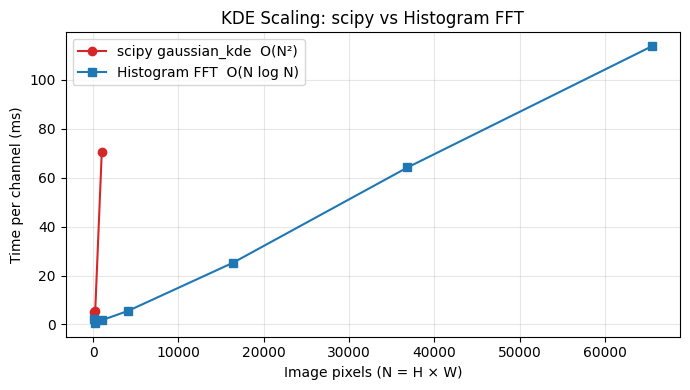

In [80]:
fig, ax = plt.subplots(figsize=(7, 4))
df_kde_plot = df_kde.dropna(subset=["scipy_ms"])
ax.plot(df_kde_plot["n_pixels"], df_kde_plot["scipy_ms"],
        "o-", label="scipy gaussian_kde  O(N²)", color="tab:red")
ax.plot(df_kde["n_pixels"], df_kde["histogram_ms"],
        "s-", label="Histogram FFT  O(N log N)", color="tab:blue")
ax.set_xlabel("Image pixels (N = H × W)")
ax.set_ylabel("Time per channel (ms)")
ax.set_title("KDE Scaling: scipy vs Histogram FFT")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 3. Load Results

Load all `timing.csv` and `convergence_log.csv` files from `saves/`, compute per-config summaries, and run FID evaluation.

In [81]:
# ── Load timing data ──────────────────────────────────────────────────────────
timing_rows = []
for timing_path in sorted(SAVES_DIR.rglob("timing.csv")):
    exp_name = timing_path.parent.name
    with open(timing_path) as f:
        row = {"experiment": exp_name}
        for line in csv.reader(f):
            if len(line) == 2:
                try:
                    row[line[0]] = float(line[1])
                except ValueError:
                    pass
        timing_rows.append(row)

df_timing = pd.DataFrame(timing_rows).fillna(0)
df_timing["config"] = df_timing["experiment"].str.replace(r"_seed\d+$", "", regex=True)
df_timing["seed"]   = df_timing["experiment"].str.extract(r"_seed(\d+)$")[0]

print(f"Loaded timing data for {len(df_timing)} experiments")
display(df_timing[["experiment", "kde_init", "fp_solve", "training", "total"]].round(2))

Loaded timing data for 54 experiments


,experiment,kde_init,fp_solve,training,total
0,celeb1_seed123,0.14,3.93,299.94,304.01
1,celeb1_seed42,0.13,4.15,312.78,317.06
2,celeb1_seed9,0.14,4.07,300.51,304.72
3,celeb3_unconditional_seed123,0.38,13.72,690.01,704.12
4,celeb3_unconditional_seed42,0.38,14.06,891.52,905.97
5,celeb3_unconditional_seed9,0.46,15.00,898.49,913.95
6,cifar1_dh05_seed123,0.08,1.36,49.74,51.18
7,cifar1_dh05_seed42,0.13,2.39,49.86,52.38
8,cifar1_dh05_seed9,0.16,1.96,54.72,56.83
9,cifar1_dh2_seed123,0.14,2.84,54.71,57.69


In [82]:
# ── Load convergence data ─────────────────────────────────────────────────────
conv_rows = []
for conv_path in sorted(SAVES_DIR.rglob("convergence_log.csv")):
    exp_name = conv_path.parent.name
    with open(conv_path) as f:
        for row in csv.DictReader(f):
            conv_rows.append({
                "experiment": exp_name,
                "config": re.sub(r"_seed\d+$", "", exp_name),
                "seed": re.search(r"_seed(\d+)$", exp_name).group(1) if re.search(r"_seed(\d+)$", exp_name) else None,
                "iteration": int(row["iteration"]),
                "data_idx": int(row["data_idx"]),
                "residual": float(row["residual"]),
                "wall_time_s": float(row["wall_time_s"]),
            })

df_conv = pd.DataFrame(conv_rows)
print(f"Loaded {len(df_conv)} convergence log entries from {df_conv['experiment'].nunique()} experiments")

# ── Load FID scores ───────────────────────────────────────────────────────────
fid_per_seed = fid_pooled = None
fid_seed_path = FIGURES_DIR / "fid_scores.csv"
fid_pool_path = FIGURES_DIR / "fid_pooled.csv"

if fid_seed_path.exists():
    fid_per_seed = pd.read_csv(fid_seed_path)
    fid_per_seed["config"] = fid_per_seed["experiment"].str.replace(r"_seed\d+$", "", regex=True)
    print(f"Loaded FID scores for {len(fid_per_seed)} experiments")
else:
    print("FID scores not yet computed — run evaluate_fid.py or the FID cell below")

if fid_pool_path.exists():
    fid_pooled = pd.read_csv(fid_pool_path)
    display(fid_pooled)

Loaded 528 convergence log entries from 54 experiments
Loaded FID scores for 51 experiments


,config,fid_pooled,n_generated,n_seeds
0,celeb1,0.429920,3,3
1,celeb3_unconditional,4.298079,9,3
2,cifar1_N10,2.328605,3,3
3,cifar1_N50,2.120132,3,3
4,cifar1_N5,2.420047,3,3
5,cifar1_dh05,2.267807,3,3
6,cifar1_dh2,2.414637,3,3
7,cifar1_dh4,2.860571,3,3
8,cifar1,2.390921,3,3
9,cifar1_sigma10,2.667835,3,3


In [83]:
# ── Display FID scores ────────────────────────────────────────────────────────
fid_seed_path = FIGURES_DIR / "fid_scores.csv"
fid_pool_path = FIGURES_DIR / "fid_pooled.csv"

if fid_seed_path.exists():
    print(f"Per-seed FID ({fid_seed_path}):")
    fid_per_seed = pd.read_csv(fid_seed_path)
    fid_per_seed["config"] = fid_per_seed["experiment"].str.replace(r"_seed\d+$", "", regex=True)
    display(fid_per_seed)
else:
    fid_per_seed = None
    print("fid_scores.csv not found — run evaluate_fid.py first.")

if fid_pool_path.exists():
    print(f"\nPooled FID ({fid_pool_path}):")
    fid_pooled = pd.read_csv(fid_pool_path)
    display(fid_pooled)
else:
    fid_pooled = None
    print("fid_pooled.csv not found.")


Per-seed FID (c:\Users\ana\Documents\GitHub\Score-Embedding-Fast-Diffusion\figures\fid_scores.csv):


,experiment,fid,n_generated,n_train,config
0,celeb1_seed123,ERROR,1,1,celeb1
1,celeb1_seed42,ERROR,1,1,celeb1
2,celeb1_seed9,ERROR,1,1,celeb1
3,celeb3_unconditional_seed123,3.9079015254974365,3,3,celeb3_unconditional
4,celeb3_unconditional_seed42,4.955004692077637,3,3,celeb3_unconditional
5,celeb3_unconditional_seed9,4.842763423919678,3,3,celeb3_unconditional
6,cifar1_N10_seed123,ERROR,1,1,cifar1_N10
7,cifar1_N10_seed42,ERROR,1,1,cifar1_N10
8,cifar1_N10_seed9,ERROR,1,1,cifar1_N10
9,cifar1_N50_seed123,ERROR,1,1,cifar1_N50



Pooled FID (c:\Users\ana\Documents\GitHub\Score-Embedding-Fast-Diffusion\figures\fid_pooled.csv):


,config,fid_pooled,n_generated,n_seeds
0,celeb1,0.429920,3,3
1,celeb3_unconditional,4.298079,9,3
2,cifar1_N10,2.328605,3,3
3,cifar1_N50,2.120132,3,3
4,cifar1_N5,2.420047,3,3
5,cifar1_dh05,2.267807,3,3
6,cifar1_dh2,2.414637,3,3
7,cifar1_dh4,2.860571,3,3
8,cifar1,2.390921,3,3
9,cifar1_sigma10,2.667835,3,3


## 4. Visualise Results

In [ ]:
# ── 6a. Convergence curves (residual norm vs FP iteration, per config) ────────
if not df_conv.empty:
    configs = df_conv["config"].unique()
    ncols = 3
    nrows = int(np.ceil(len(configs) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows), squeeze=False)
    fig.suptitle("FP Solver Convergence (residual vs iteration)", fontsize=13)

    for ax, cfg in zip(axes.flat, configs):
        sub = df_conv[df_conv["config"] == cfg]
        for seed, grp in sub.groupby("seed"):
            # average residual across data_idx for each iteration
            mean_res = grp.groupby("iteration")["residual"].mean()
            ax.semilogy(mean_res.index, mean_res.values, label=f"seed {seed}", alpha=0.8)
        ax.set_title(cfg, fontsize=9)
        ax.set_xlabel("Iteration")
        ax.set_ylabel("Residual norm")
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

    for ax in axes.flat[len(configs):]:
        ax.axis("off")

    fig.tight_layout()
    plt.show()
else:
    print("No convergence data loaded yet.")

In [ ]:
# ── 6b. Runtime breakdown (stacked bars: kde_init / fp_solve / training) ──────
if not df_timing.empty:
    main_configs = ["cifar1", "cifar3_conditional", "cifar3_unconditional",
                    "celeb1", "celeb3_unconditional", "inet3_conditional"]
    df_main = df_timing[df_timing["config"].isin(main_configs)].copy()

    # Mean across seeds
    time_cols = [c for c in ["kde_init", "fp_solve", "training"] if c in df_main.columns]
    df_mean = df_main.groupby("config")[time_cols].mean().loc[
        [c for c in main_configs if c in df_main["config"].values]
    ]

    fig, ax = plt.subplots(figsize=(9, 4))
    bottom = np.zeros(len(df_mean))
    colors = ["#4c78a8", "#f58518", "#54a24b"]
    for col, color in zip(time_cols, colors):
        if col in df_mean.columns:
            ax.bar(df_mean.index, df_mean[col], bottom=bottom, label=col, color=color)
            bottom += df_mean[col].values

    ax.set_ylabel("Time (s)")
    ax.set_title("Runtime Breakdown (mean across seeds)")
    ax.legend()
    ax.set_xticklabels(df_mean.index, rotation=20, ha="right")
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    plt.show()
else:
    print("No timing data loaded yet.")

In [ ]:
# ── 6c. FID bar chart (per-seed + pooled) ─────────────────────────────────────
if fid_per_seed is not None:
    df_fid = fid_per_seed[fid_per_seed["fid"] != "ERROR"].copy()
    df_fid["fid"] = df_fid["fid"].astype(float)

    configs = df_fid["config"].unique()
    x = np.arange(len(configs))
    seeds = sorted(df_fid["experiment"].str.extract(r"_seed(\d+)$")[0].dropna().unique(),
                   key=int)
    width = 0.2

    fig, ax = plt.subplots(figsize=(10, 4))
    for i, seed in enumerate(seeds):
        vals = []
        for cfg in configs:
            row = df_fid[df_fid["experiment"] == f"{cfg}_seed{seed}"]
            vals.append(row["fid"].values[0] if len(row) else np.nan)
        ax.bar(x + i * width, vals, width, label=f"seed {seed}", alpha=0.8)

    # Pooled FID markers
    if fid_pooled is not None:
        for j, cfg in enumerate(configs):
            row = fid_pooled[fid_pooled["config"] == cfg]
            if len(row):
                ax.hlines(row["fid_pooled"].values[0],
                          x[j] - 0.05, x[j] + len(seeds) * width + 0.05,
                          colors="black", linestyles="dashed", linewidth=1.5)

    ax.set_xticks(x + width)
    ax.set_xticklabels(configs, rotation=20, ha="right")
    ax.set_ylabel("FID (feature=64)")
    ax.set_title("FID per Seed  (dashed = pooled across seeds)")
    ax.legend(title="Seed")
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    plt.show()
else:
    print("FID data not available yet.")

In [ ]:
# ── 6d. KDE scaling plot (from Section 3) ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: absolute timing
df_kde_plot = df_kde.dropna(subset=["scipy_ms"])
axes[0].plot(df_kde_plot["n_pixels"], df_kde_plot["scipy_ms"],
             "o-", color="tab:red", label="scipy  O(N²)")
axes[0].plot(df_kde["n_pixels"], df_kde["histogram_ms"],
             "s-", color="tab:blue", label="Histogram FFT  O(N log N)")
axes[0].set_xlabel("N pixels (H × W)")
axes[0].set_ylabel("Time per channel (ms)")
axes[0].set_title("KDE Timing vs Image Size")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: speedup factor
df_sp = df_kde.dropna(subset=["speedup"])
axes[1].bar(df_sp["resolution"], df_sp["speedup"], color="tab:green")
axes[1].set_xlabel("Resolution")
axes[1].set_ylabel("Speedup factor (scipy / histogram)")
axes[1].set_title("Speedup: Histogram FFT over scipy KDE")
axes[1].grid(axis="y", alpha=0.3)
for i, (_, row) in enumerate(df_sp.iterrows()):
    axes[1].text(i, row["speedup"] + 0.3, f"{row['speedup']:.0f}×",
                 ha="center", fontsize=9)

fig.tight_layout()
plt.show()

In [ ]:
# ── 6e. Generated sample grids (last sample per experiment) ───────────────────
def _load_samples(folder):
    """Load samples as (n_samples, 1, C, H, W), trying samples.npy then samples/ dir."""
    p = folder / "samples.npy"
    if p.exists():
        raw = np.load(p)
        if raw.ndim == 4:          # (n_samples, C, H, W) -> add n_train dim
            raw = raw[:, np.newaxis]
        return raw
    samples_dir = folder / "samples"
    if samples_dir.is_dir():
        files = sorted(samples_dir.glob("*.npy"))
        if files:
            # Use the last file (most converged checkpoint)
            a = np.load(str(files[-1]))
            while a.ndim < 5:
                a = a[np.newaxis]
            return a  # (n_samples, 1, C, H, W)
    return None

def show_sample_grid(config_name, max_seeds=3, samples_to_show=8):
    """Show generated samples for a config across seeds — one row per seed."""
    folders = sorted(SAVES_DIR.glob(f"{config_name}_seed*"))[:max_seeds]
    if not folders:
        print(f"No saves found for {config_name}")
        return

    # Pre-load data; skip folders with no samples
    rows_data = []
    n_gt = 0
    for folder in folders:
        raw = _load_samples(folder)
        if raw is None:
            print(f"  No samples found in {folder.name}, skipping.")
            continue
        gt = np.load(folder / "dataset.npy")   # (n_train, C, H, W)
        seed = folder.name.split("_seed")[-1]
        rows_data.append((seed, gt, raw))
        n_gt = max(n_gt, gt.shape[0])

    if not rows_data:
        print(f"Nothing to display for {config_name}")
        return

    ncols = n_gt + samples_to_show
    nrows = len(rows_data)
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(1.8 * ncols, 2.2 * nrows),
                             squeeze=False)
    fig.suptitle(config_name, fontsize=12)

    for row, (seed, gt, raw) in enumerate(rows_data):
        col = 0
        # Ground-truth columns
        for i in range(gt.shape[0]):
            img = torch.from_numpy(gt[i]).clamp(0, 1).permute(1, 2, 0).numpy()
            axes[row, col].imshow(img)
            axes[row, col].set_title(f"GT {i+1}\n(seed {seed})", fontsize=6)
            axes[row, col].axis("off")
            col += 1
        # Generated-sample columns
        for s in range(min(samples_to_show, raw.shape[0])):
            img = torch.from_numpy(raw[s, 0]).float()
            img = (img - img.min()) / (img.max() - img.min() + 1e-8)
            axes[row, col].imshow(img.clamp(0, 1).permute(1, 2, 0).numpy())
            axes[row, col].set_title(f"Gen {s+1}\n(seed {seed})", fontsize=6)
            axes[row, col].axis("off")
            col += 1
        # Blank remaining columns
        for c in range(col, ncols):
            axes[row, c].axis("off")

    fig.tight_layout()
    plt.show()

for cfg in ["cifar1", "cifar3_conditional", "celeb1", "celeb3_unconditional"]:
    show_sample_grid(cfg)